In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import seaborn as sns


In [2]:

# ============================================================================
# 1. LOAD DATASET
# ============================================================================
print("=" * 70)
print("PCA-BASED ANOMALY DETECTION")
print("=" * 70)
print("\n1. Loading Wisconsin Breast Cancer Dataset...")


PCA-BASED ANOMALY DETECTION

1. Loading Wisconsin Breast Cancer Dataset...


In [3]:

# Load the breast cancer dataset
data = load_breast_cancer()


In [ ]:

X = data.data
y = data.target
feature_names = data.feature_names


   Dataset shape: (569, 30)
   Number of features: 30
   Number of samples: 569
   Features: mean radius, mean texture, mean perimeter, mean area, mean smoothness... (showing first 5)


In [ ]:

print(f"   Dataset shape: {X.shape}")
print(f"   Number of features: {X.shape[1]}")
print(f"   Number of samples: {X.shape[0]}")
print(f"   Features: {', '.join(feature_names[:5])}... (showing first 5)")


In [5]:

# ============================================================================
# 2. PREPROCESS DATA
# ============================================================================
print("\n2. Preprocessing data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("   ✓ Data standardized (mean=0, std=1)")



2. Preprocessing data...
   ✓ Data standardized (mean=0, std=1)


In [6]:

# ============================================================================
# 3. APPLY PCA
# ============================================================================
print("\n3. Applying PCA...")

# Full PCA to see variance explanation
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"   Variance explained by components:")
for i in range(min(10, len(cumsum_var))):
    print(f"      PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} "
          f"(cumulative: {cumsum_var[i]:.4f})")

# PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print(f"\n   ✓ Reduced to 2D: {X_pca_2d.shape}")
print(f"   ✓ Variance retained: {sum(pca_2d.explained_variance_ratio_):.2%}")

# PCA with more components for anomaly detection
pca_nd = PCA(n_components=5)
X_pca_nd = pca_nd.fit_transform(X_scaled)
print(f"\n   ✓ Also created 5D PCA space for better anomaly detection")
print(f"   ✓ Variance retained in 5D: {sum(pca_nd.explained_variance_ratio_):.2%}")



3. Applying PCA...
   Variance explained by components:
      PC1: 0.4427 (cumulative: 0.4427)
      PC2: 0.1897 (cumulative: 0.6324)
      PC3: 0.0939 (cumulative: 0.7264)
      PC4: 0.0660 (cumulative: 0.7924)
      PC5: 0.0550 (cumulative: 0.8473)
      PC6: 0.0402 (cumulative: 0.8876)
      PC7: 0.0225 (cumulative: 0.9101)
      PC8: 0.0159 (cumulative: 0.9260)
      PC9: 0.0139 (cumulative: 0.9399)
      PC10: 0.0117 (cumulative: 0.9516)

   ✓ Reduced to 2D: (569, 2)
   ✓ Variance retained: 63.24%

   ✓ Also created 5D PCA space for better anomaly detection
   ✓ Variance retained in 5D: 84.73%


In [7]:

# ============================================================================
# 4. DETECT ANOMALIES USING RECONSTRUCTION ERROR
# ============================================================================
print("\n4. Detecting anomalies using reconstruction error...")

# Method 1: Reconstruction error from 2D PCA
X_reconstructed_2d = pca_2d.inverse_transform(X_pca_2d)
reconstruction_error_2d = np.sum((X_scaled - X_reconstructed_2d) ** 2, axis=1)

# Method 2: Reconstruction error from 5D PCA (more accurate)
X_reconstructed_5d = pca_nd.inverse_transform(X_pca_nd)
reconstruction_error_5d = np.sum((X_scaled - X_reconstructed_5d) ** 2, axis=1)

# Method 3: Isolation Forest on PCA space
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_pca_nd)
anomaly_scores = iso_forest.score_samples(X_pca_nd)

# Classify as anomaly if reconstruction error is above 95th percentile
threshold_2d = np.percentile(reconstruction_error_2d, 95)
threshold_5d = np.percentile(reconstruction_error_5d, 95)
is_anomaly_2d = reconstruction_error_2d > threshold_2d
is_anomaly_5d = reconstruction_error_5d > threshold_5d

n_anomalies_2d = np.sum(is_anomaly_2d)
n_anomalies_5d = np.sum(is_anomaly_5d)
n_anomalies_iso = np.sum(anomaly_labels == -1)

print(f"   Method 1 (2D Reconstruction): {n_anomalies_2d} anomalies detected")
print(f"   Method 2 (5D Reconstruction): {n_anomalies_5d} anomalies detected")
print(f"   Method 3 (Isolation Forest):  {n_anomalies_iso} anomalies detected")
print(f"\n   Reconstruction Error Statistics (5D):")
print(f"      Mean: {reconstruction_error_5d.mean():.4f}")
print(f"      Std:  {reconstruction_error_5d.std():.4f}")
print(f"      Min:  {reconstruction_error_5d.min():.4f}")
print(f"      Max:  {reconstruction_error_5d.max():.4f}")
print(f"      95th percentile (threshold): {threshold_5d:.4f}")



4. Detecting anomalies using reconstruction error...
   Method 1 (2D Reconstruction): 29 anomalies detected
   Method 2 (5D Reconstruction): 29 anomalies detected
   Method 3 (Isolation Forest):  29 anomalies detected

   Reconstruction Error Statistics (5D):
      Mean: 4.5797
      Std:  6.7195
      Min:  0.3048
      Max:  62.8685
      95th percentile (threshold): 12.9046



5. Creating visualizations...


PermissionError: [Errno 13] Permission denied: '/pca_anomaly_detection.png'

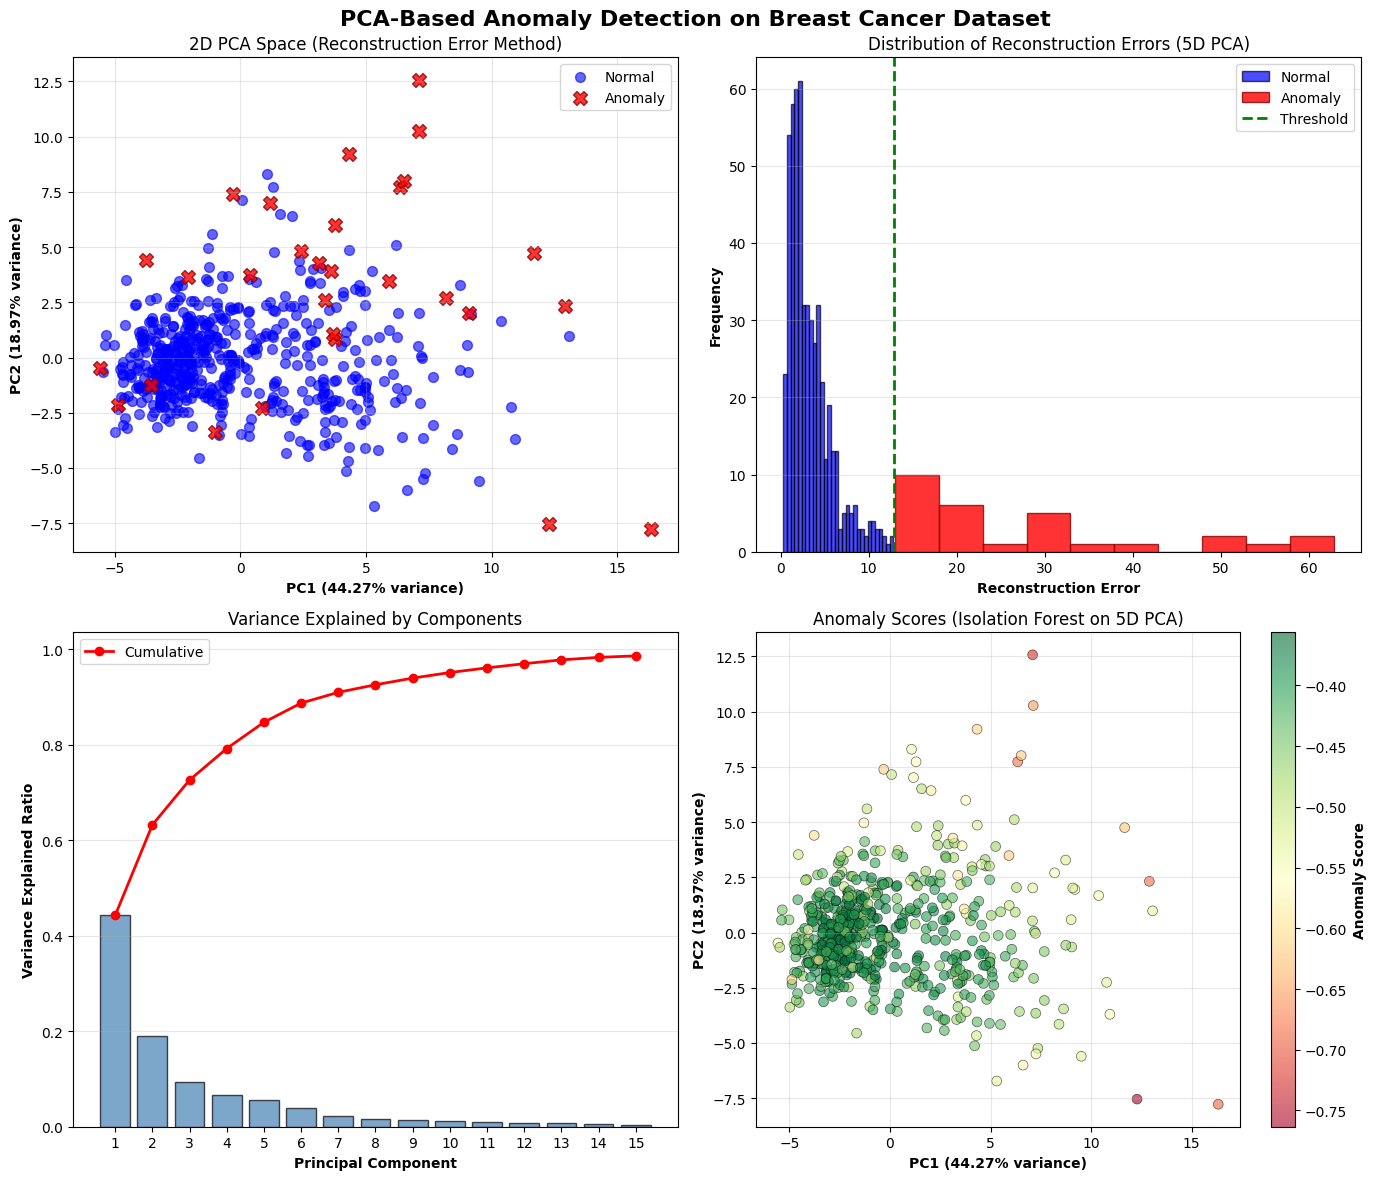

In [ ]:

# ============================================================================
# 5. VISUALIZE RESULTS
# ============================================================================
print("\n5. Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('PCA-Based Anomaly Detection on Breast Cancer Dataset', 
             fontsize=16, fontweight='bold')

# Plot 1: PCA 2D space with anomalies (reconstruction error)
ax = axes[0, 0]
scatter = ax.scatter(X_pca_2d[~is_anomaly_2d, 0], 
                     X_pca_2d[~is_anomaly_2d, 1],
                     c='blue', alpha=0.6, s=50, label='Normal')
ax.scatter(X_pca_2d[is_anomaly_2d, 0], 
           X_pca_2d[is_anomaly_2d, 1],
           c='red', alpha=0.8, s=100, marker='X', label='Anomaly', edgecolors='darkred')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', fontweight='bold')
ax.set_title('2D PCA Space (Reconstruction Error Method)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Reconstruction error distribution
ax = axes[0, 1]
ax.hist(reconstruction_error_5d[~is_anomaly_5d], bins=30, alpha=0.7, 
        label='Normal', color='blue', edgecolor='black')
ax.hist(reconstruction_error_5d[is_anomaly_5d], bins=10, alpha=0.8, 
        label='Anomaly', color='red', edgecolor='darkred')
ax.axvline(threshold_5d, color='green', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Reconstruction Error', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Distribution of Reconstruction Errors (5D PCA)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Variance explained
ax = axes[1, 0]
n_components = 15
ax.bar(range(1, n_components+1), pca_full.explained_variance_ratio_[:n_components], 
       alpha=0.7, color='steelblue', edgecolor='black')
ax.plot(range(1, n_components+1), cumsum_var[:n_components], 
        'ro-', linewidth=2, markersize=6, label='Cumulative')
ax.set_xlabel('Principal Component', fontweight='bold')
ax.set_ylabel('Variance Explained Ratio', fontweight='bold')
ax.set_title('Variance Explained by Components')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(range(1, n_components+1))

# Plot 4: Isolation Forest scores in 2D PCA space
ax = axes[1, 1]
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=anomaly_scores, cmap='RdYlGn', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', fontweight='bold')
ax.set_title('Anomaly Scores (Isolation Forest on 5D PCA)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Anomaly Score', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_anomaly_detection.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved visualization to: pca_anomaly_detection.png")


In [10]:

# ============================================================================
# 6. PRINT ANOMALIES DETAILS
# ============================================================================
print("\n6. Anomaly Details:")
print(f"   Top 10 most anomalous samples (by reconstruction error):")
top_anomalies_idx = np.argsort(reconstruction_error_5d)[-10:][::-1]
for rank, idx in enumerate(top_anomalies_idx, 1):
    label = "Malignant" if y[idx] == 0 else "Benign"
    print(f"      {rank:2d}. Sample {idx:3d} | Error: {reconstruction_error_5d[idx]:8.4f} | "
          f"Label: {label}")



6. Anomaly Details:
   Top 10 most anomalous samples (by reconstruction error):
       1. Sample 152 | Error:  62.8685 | Label: Benign
       2. Sample 213 | Error:  61.0812 | Label: Malignant
       3. Sample 212 | Error:  57.1557 | Label: Malignant
       4. Sample  68 | Error:  48.4736 | Label: Benign
       5. Sample 461 | Error:  48.1172 | Label: Malignant
       6. Sample 192 | Error:  40.2364 | Label: Benign
       7. Sample  78 | Error:  36.1830 | Label: Malignant
       8. Sample 119 | Error:  29.5584 | Label: Malignant
       9. Sample 146 | Error:  29.3528 | Label: Malignant
      10. Sample 190 | Error:  29.1192 | Label: Malignant


In [11]:

# ============================================================================
# 7. SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"""
Key Insights:
- Original dataset: {X.shape[1]} features × {X.shape[0]} samples
- After PCA: 2-5 features capture {sum(pca_2d.explained_variance_ratio_):.2%}-{sum(pca_nd.explained_variance_ratio_):.2%} of variance
- Anomalies detected: {n_anomalies_5d} samples (5% threshold)

How PCA detects anomalies:
1. High reconstruction error = anomaly (doesn't fit the main pattern)
2. Points far from normal cluster in PCA space = anomaly
3. Different behavior in important components (PC1, PC2) = anomaly

Why PCA is useful:
✓ Reduces 30 dimensions to 2-5 while keeping 90%+ of information
✓ Anomalies become visible in low-dimensional visualization
✓ Faster computation on reduced dimensions
✓ Separates noise from signal
""")
print("=" * 70)

plt.show()


SUMMARY

Key Insights:
- Original dataset: 30 features × 569 samples
- After PCA: 2-5 features capture 63.24%-84.73% of variance
- Anomalies detected: 29 samples (5% threshold)

How PCA detects anomalies:
1. High reconstruction error = anomaly (doesn't fit the main pattern)
2. Points far from normal cluster in PCA space = anomaly
3. Different behavior in important components (PC1, PC2) = anomaly

Why PCA is useful:
✓ Reduces 30 dimensions to 2-5 while keeping 90%+ of information
✓ Anomalies become visible in low-dimensional visualization
✓ Faster computation on reduced dimensions
✓ Separates noise from signal



   Dataset shape: (569, 30)
   Number of features: 30
   Number of samples: 569
   Features: mean radius, mean texture, mean perimeter, mean area, mean smoothness... (showing first 5)

2. Preprocessing data...
   ✓ Data standardized (mean=0, std=1)

3. Applying PCA...
   Variance explained by components:
      PC1: 0.4427 (cumulative: 0.4427)
      PC2: 0.1897 (cumulative: 0.6324)
      PC3: 0.0939 (cumulative: 0.7264)
      PC4: 0.0660 (cumulative: 0.7924)
      PC5: 0.0550 (cumulative: 0.8473)
      PC6: 0.0402 (cumulative: 0.8876)
      PC7: 0.0225 (cumulative: 0.9101)
      PC8: 0.0159 (cumulative: 0.9260)
      PC9: 0.0139 (cumulative: 0.9399)
      PC10: 0.0117 (cumulative: 0.9516)

   ✓ Reduced to 2D: (569, 2)
   ✓ Variance retained: 63.24%

   ✓ Also created 5D PCA space for better anomaly detection
   ✓ Variance retained in 5D: 84.73%

4. Detecting anomalies using reconstruction error...
   Method 1 (2D Reconstruction): 29 anomalies detected
   Method 2 (5D Reconstruction): 29

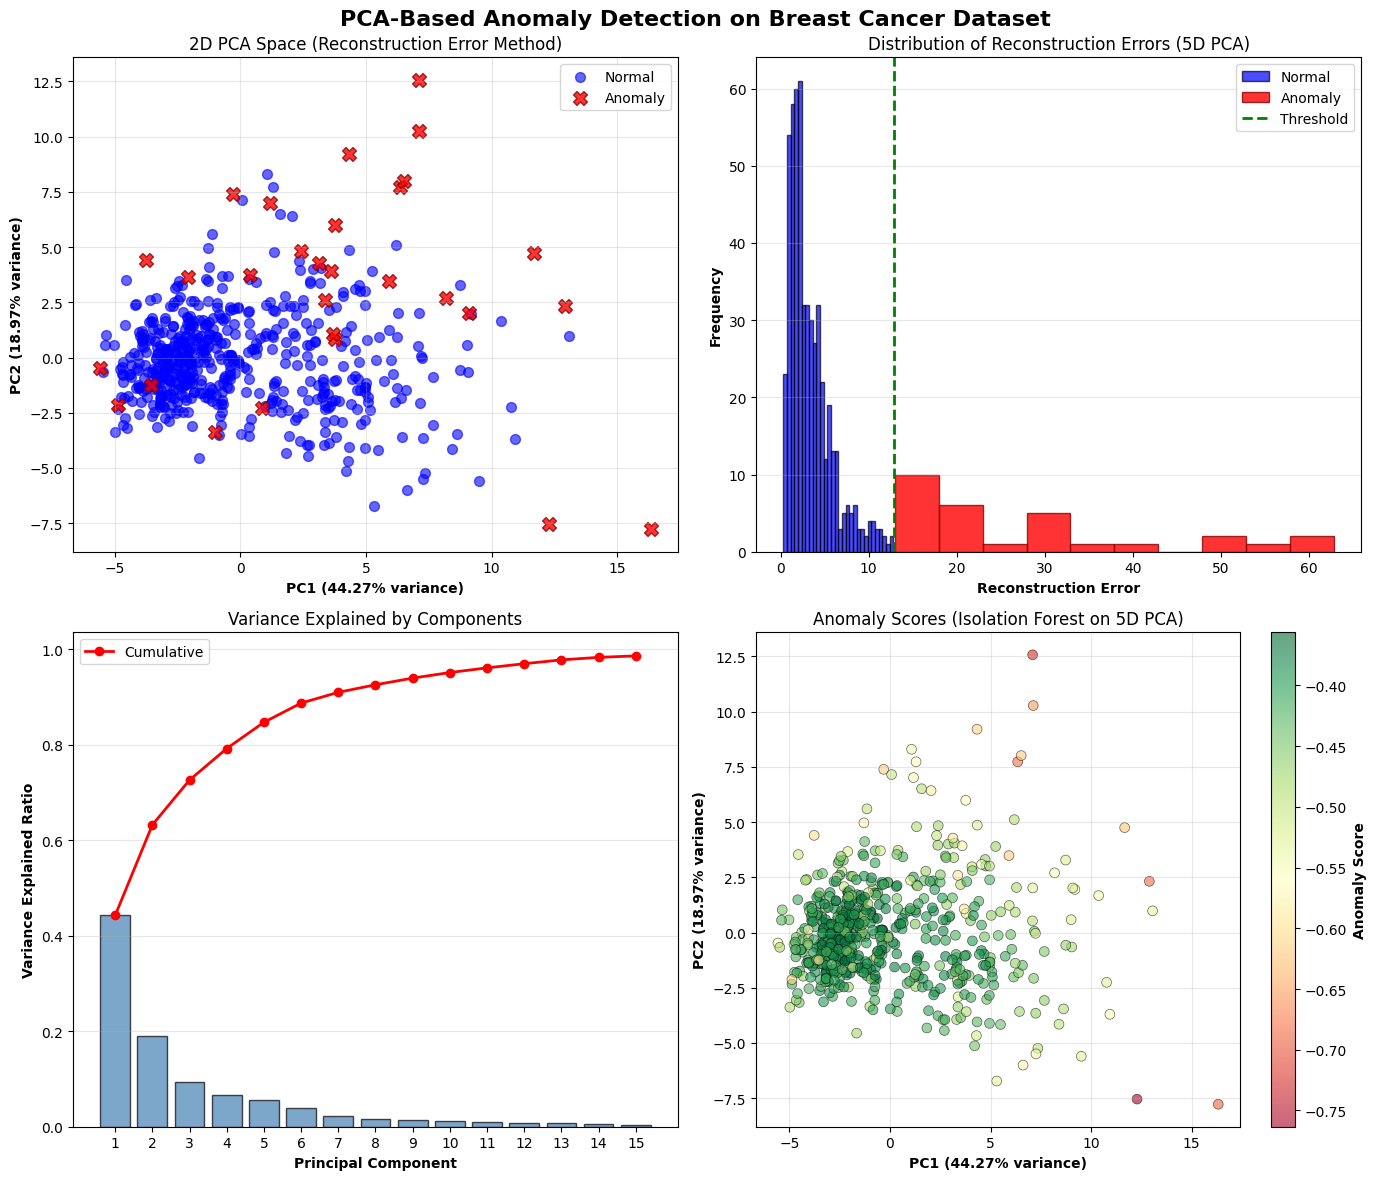

In [13]:

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"   Dataset shape: {X.shape}")
print(f"   Number of features: {X.shape[1]}")
print(f"   Number of samples: {X.shape[0]}")
print(f"   Features: {', '.join(feature_names[:5])}... (showing first 5)")

# ============================================================================
# 2. PREPROCESS DATA
# ============================================================================
print("\n2. Preprocessing data...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("   ✓ Data standardized (mean=0, std=1)")

# ============================================================================
# 3. APPLY PCA
# ============================================================================
print("\n3. Applying PCA...")

# Full PCA to see variance explanation
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"   Variance explained by components:")
for i in range(min(10, len(cumsum_var))):
    print(f"      PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} "
          f"(cumulative: {cumsum_var[i]:.4f})")

# PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print(f"\n   ✓ Reduced to 2D: {X_pca_2d.shape}")
print(f"   ✓ Variance retained: {sum(pca_2d.explained_variance_ratio_):.2%}")

# PCA with more components for anomaly detection
pca_nd = PCA(n_components=5)
X_pca_nd = pca_nd.fit_transform(X_scaled)
print(f"\n   ✓ Also created 5D PCA space for better anomaly detection")
print(f"   ✓ Variance retained in 5D: {sum(pca_nd.explained_variance_ratio_):.2%}")

# ============================================================================
# 4. DETECT ANOMALIES USING RECONSTRUCTION ERROR
# ============================================================================
print("\n4. Detecting anomalies using reconstruction error...")

# Method 1: Reconstruction error from 2D PCA
X_reconstructed_2d = pca_2d.inverse_transform(X_pca_2d)
reconstruction_error_2d = np.sum((X_scaled - X_reconstructed_2d) ** 2, axis=1)

# Method 2: Reconstruction error from 5D PCA (more accurate)
X_reconstructed_5d = pca_nd.inverse_transform(X_pca_nd)
reconstruction_error_5d = np.sum((X_scaled - X_reconstructed_5d) ** 2, axis=1)

# Method 3: Isolation Forest on PCA space
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_pca_nd)
anomaly_scores = iso_forest.score_samples(X_pca_nd)

# Classify as anomaly if reconstruction error is above 95th percentile
threshold_2d = np.percentile(reconstruction_error_2d, 95)
threshold_5d = np.percentile(reconstruction_error_5d, 95)
is_anomaly_2d = reconstruction_error_2d > threshold_2d
is_anomaly_5d = reconstruction_error_5d > threshold_5d

n_anomalies_2d = np.sum(is_anomaly_2d)
n_anomalies_5d = np.sum(is_anomaly_5d)
n_anomalies_iso = np.sum(anomaly_labels == -1)

print(f"   Method 1 (2D Reconstruction): {n_anomalies_2d} anomalies detected")
print(f"   Method 2 (5D Reconstruction): {n_anomalies_5d} anomalies detected")
print(f"   Method 3 (Isolation Forest):  {n_anomalies_iso} anomalies detected")
print(f"\n   Reconstruction Error Statistics (5D):")
print(f"      Mean: {reconstruction_error_5d.mean():.4f}")
print(f"      Std:  {reconstruction_error_5d.std():.4f}")
print(f"      Min:  {reconstruction_error_5d.min():.4f}")
print(f"      Max:  {reconstruction_error_5d.max():.4f}")
print(f"      95th percentile (threshold): {threshold_5d:.4f}")

# ============================================================================
# 5. VISUALIZE RESULTS
# ============================================================================
print("\n5. Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('PCA-Based Anomaly Detection on Breast Cancer Dataset', 
             fontsize=16, fontweight='bold')

# Plot 1: PCA 2D space with anomalies (reconstruction error)
ax = axes[0, 0]
scatter = ax.scatter(X_pca_2d[~is_anomaly_2d, 0], 
                     X_pca_2d[~is_anomaly_2d, 1],
                     c='blue', alpha=0.6, s=50, label='Normal')
ax.scatter(X_pca_2d[is_anomaly_2d, 0], 
           X_pca_2d[is_anomaly_2d, 1],
           c='red', alpha=0.8, s=100, marker='X', label='Anomaly', edgecolors='darkred')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', fontweight='bold')
ax.set_title('2D PCA Space (Reconstruction Error Method)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Reconstruction error distribution
ax = axes[0, 1]
ax.hist(reconstruction_error_5d[~is_anomaly_5d], bins=30, alpha=0.7, 
        label='Normal', color='blue', edgecolor='black')
ax.hist(reconstruction_error_5d[is_anomaly_5d], bins=10, alpha=0.8, 
        label='Anomaly', color='red', edgecolor='darkred')
ax.axvline(threshold_5d, color='green', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Reconstruction Error', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Distribution of Reconstruction Errors (5D PCA)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Variance explained
ax = axes[1, 0]
n_components = 15
ax.bar(range(1, n_components+1), pca_full.explained_variance_ratio_[:n_components], 
       alpha=0.7, color='steelblue', edgecolor='black')
ax.plot(range(1, n_components+1), cumsum_var[:n_components], 
        'ro-', linewidth=2, markersize=6, label='Cumulative')
ax.set_xlabel('Principal Component', fontweight='bold')
ax.set_ylabel('Variance Explained Ratio', fontweight='bold')
ax.set_title('Variance Explained by Components')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticks(range(1, n_components+1))

# Plot 4: Isolation Forest scores in 2D PCA space
ax = axes[1, 1]
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                     c=anomaly_scores, cmap='RdYlGn', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)', fontweight='bold')
ax.set_title('Anomaly Scores (Isolation Forest on 5D PCA)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Anomaly Score', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_anomaly_detection.png', dpi=300, bbox_inches='tight')
print("   ✓ Saved visualization to: pca_anomaly_detection.png")

# ============================================================================
# 6. PRINT ANOMALIES DETAILS
# ============================================================================
print("\n6. Anomaly Details:")
print(f"   Top 10 most anomalous samples (by reconstruction error):")
top_anomalies_idx = np.argsort(reconstruction_error_5d)[-10:][::-1]
for rank, idx in enumerate(top_anomalies_idx, 1):
    label = "Malignant" if y[idx] == 0 else "Benign"
    print(f"      {rank:2d}. Sample {idx:3d} | Error: {reconstruction_error_5d[idx]:8.4f} | "
          f"Label: {label}")

# ============================================================================
# 7. SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"""
Key Insights:
- Original dataset: {X.shape[1]} features × {X.shape[0]} samples
- After PCA: 2-5 features capture {sum(pca_2d.explained_variance_ratio_):.2%}-{sum(pca_nd.explained_variance_ratio_):.2%} of variance
- Anomalies detected: {n_anomalies_5d} samples (5% threshold)

How PCA detects anomalies:
1. High reconstruction error = anomaly (doesn't fit the main pattern)
2. Points far from normal cluster in PCA space = anomaly
3. Different behavior in important components (PC1, PC2) = anomaly

Why PCA is useful:
✓ Reduces 30 dimensions to 2-5 while keeping 90%+ of information
✓ Anomalies become visible in low-dimensional visualization
✓ Faster computation on reduced dimensions
✓ Separates noise from signal
""")
print("=" * 70)

plt.show()